<a href="https://www.kaggle.com/code/saurabhanand56/google-playstore-data-analysis?scriptVersionId=339657582" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
# ===============================
# Google Play Store Data Analysis
# ===============================

# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [3]:
!git clone https://github.com/SaurabhAnand56/google_playstore_data_analysis.git

Cloning into 'google_playstore_data_analysis'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 13 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 354.40 KiB | 672.00 KiB/s, done.
Resolving deltas: 100% (4/4), done.


In [4]:
import os
os.listdir("google_playstore_data_analysis")

['.git',
 'Google Play Store Data Analysis.ipynb',
 'googleplaystore.csv',
 'README.md']

In [5]:
# Load dataset
df = pd.read_csv(
    "google_playstore_data_analysis/googleplaystore.csv"
)

df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [6]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [7]:
# Missing Values

missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

Rating            1474
Current Ver          8
Android Ver          3
Content Rating       1
Type                 1
dtype: int64

In [8]:
# Summary Statistics

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
App,10841,9660,ROBLOX,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,10841,34,FAMILY,1972,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,9367.0,NaN,NaN,NaN,4.193338,0.537431,1.0,4.0,4.3,4.5,19.0
Reviews,10841,6002,0,596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,10841,462,Varies with device,1695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Installs,10841,22,"1,000,000+",1579,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10840,3,Free,10039,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,10841,93,0,10040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Content Rating,10840,6,Everyone,8714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Genres,10841,120,Tools,842,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Number of duplicate rows

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 483


In [10]:
# Display column names

df.columns.tolist()

['App',
 'Category',
 'Rating',
 'Reviews',
 'Size',
 'Installs',
 'Type',
 'Price',
 'Content Rating',
 'Genres',
 'Last Updated',
 'Current Ver',
 'Android Ver']

In [11]:
# Remove duplicates

df = df.drop_duplicates()

# Remove rows where App is missing

df.dropna(subset=["App"], inplace=True)

In [12]:
# Convert Reviews to numeric

df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

In [13]:
def clean_size(size):

    if pd.isna(size):
        return np.nan

    size = str(size)

    if size == "Varies with device":
        return np.nan

    if "M" in size:
        return float(size.replace("M",""))

    if "k" in size:
        return float(size.replace("k",""))/1024

    return np.nan


df["Size"] = df["Size"].apply(clean_size)

In [14]:
df["Installs"] = (
    df["Installs"]
    .str.replace(",","",regex=False)
    .str.replace("+","",regex=False)
)

df["Installs"] = pd.to_numeric(df["Installs"],errors="coerce")

In [15]:
df["Price"] = (
    df["Price"]
    .str.replace("$","",regex=False)
)

df["Price"] = pd.to_numeric(df["Price"],errors="coerce")

In [16]:
df["Rating"] = pd.to_numeric(df["Rating"],errors="coerce")

In [17]:
df.isnull().sum()

App                  0
Category             0
Rating            1465
Reviews              1
Size              1527
Installs             1
Type                 1
Price                1
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [18]:
print("Rows :",df.shape[0])

print("Columns :",df.shape[1])

Rows : 10358
Columns : 13


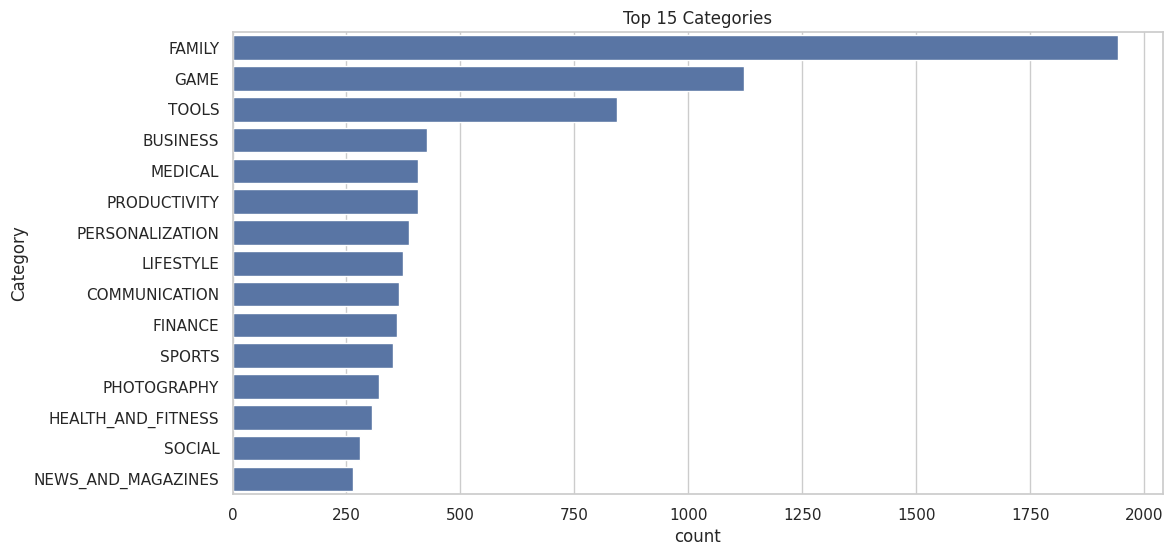

In [19]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="Category",
    order=df["Category"].value_counts().index[:15]
)

plt.title("Top 15 Categories")

plt.show()

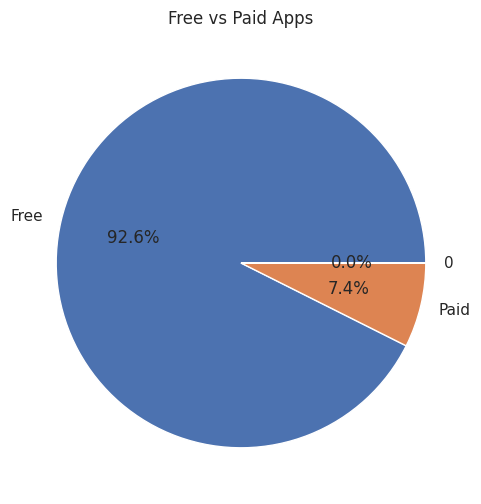

In [20]:
plt.figure(figsize=(6,6))

df["Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Free vs Paid Apps")

plt.show()

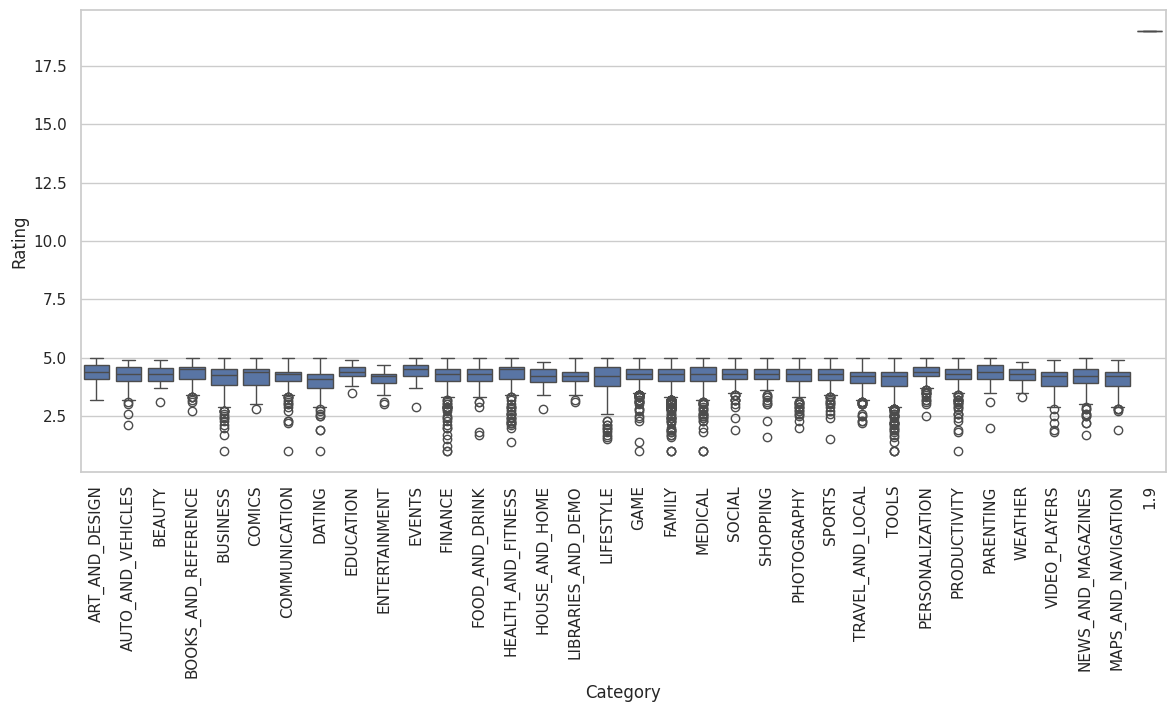

In [21]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x="Category",
    y="Rating"
)

plt.xticks(rotation=90)

plt.show()

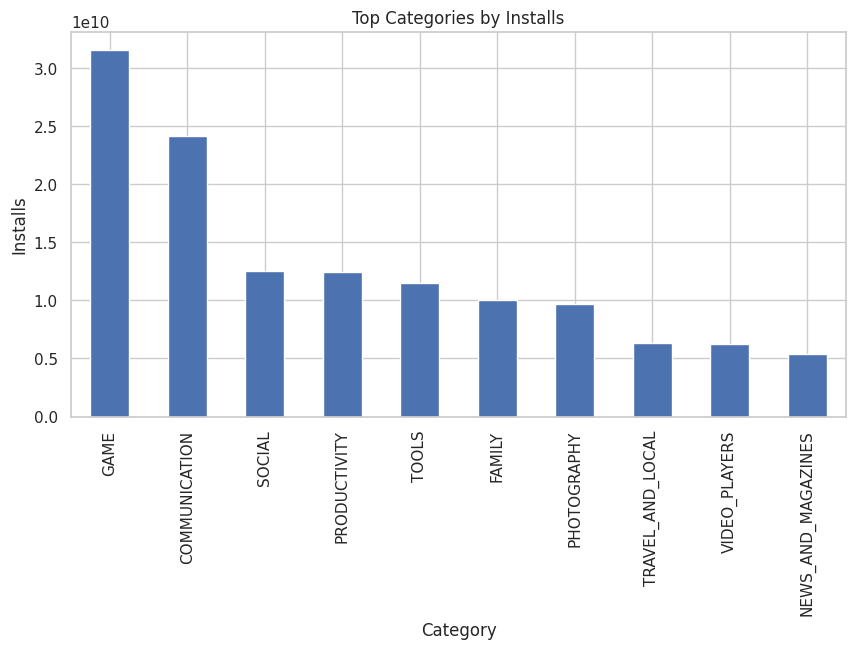

In [22]:
top_installs = (
    df.groupby("Category")["Installs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_installs.plot(kind="bar")

plt.title("Top Categories by Installs")

plt.ylabel("Installs")

plt.show()

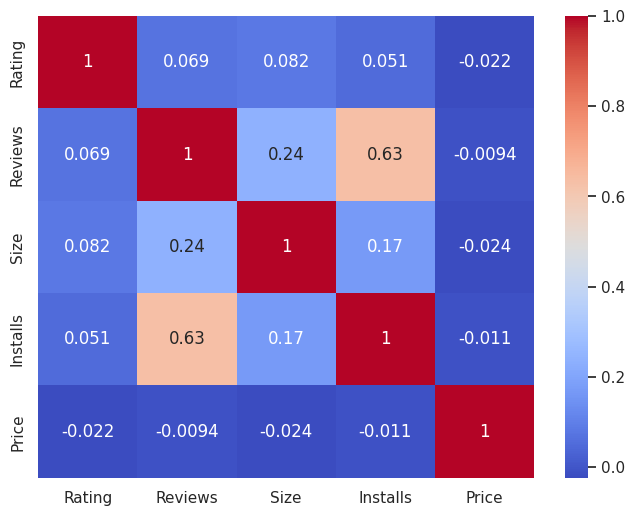

In [23]:
numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

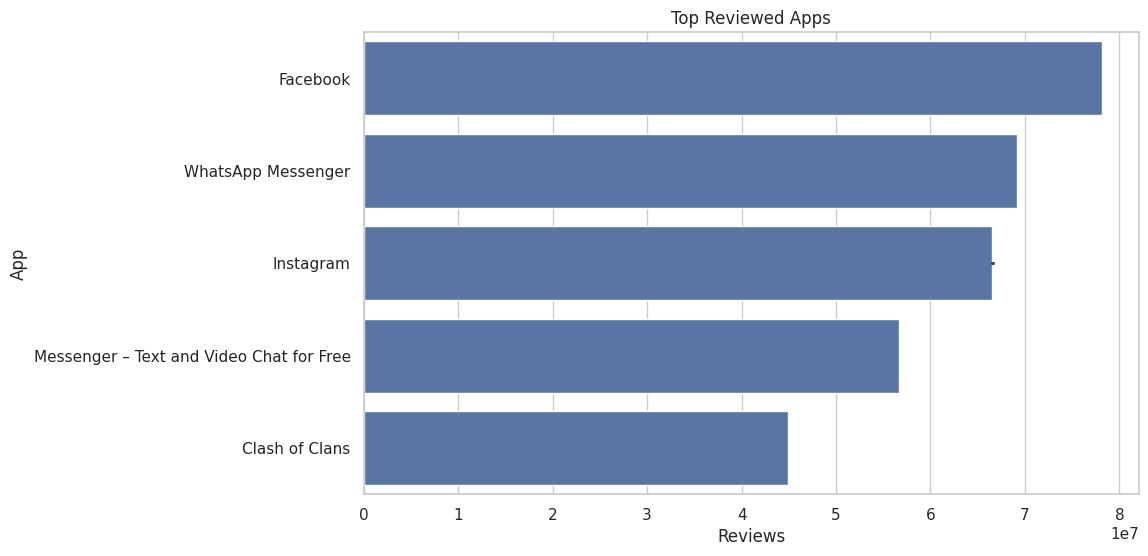

In [24]:
top_reviews = (
    df.sort_values("Reviews",ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_reviews,
    x="Reviews",
    y="App"
)

plt.title("Top Reviewed Apps")

plt.show()

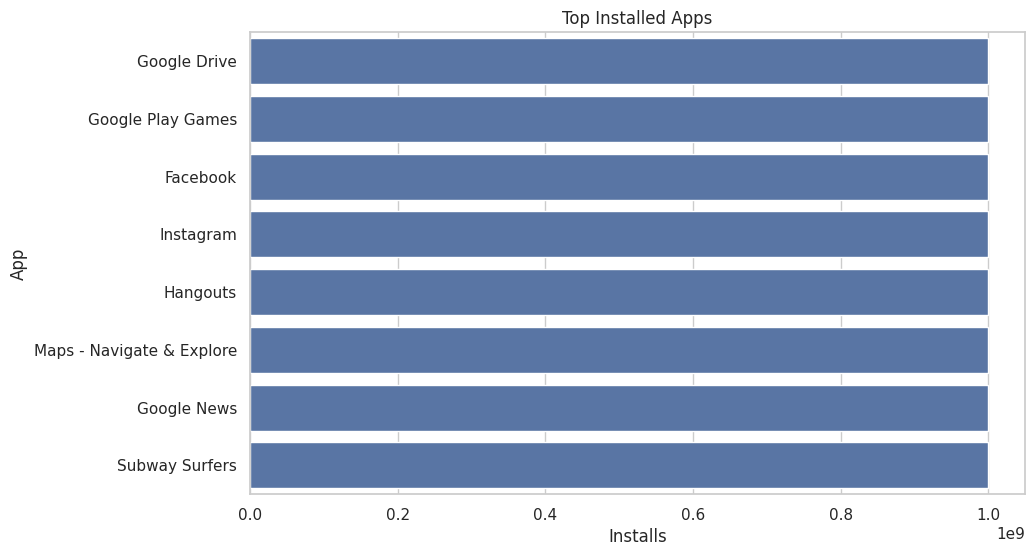

In [25]:
top_apps = (
    df.sort_values("Installs",ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_apps,
    x="Installs",
    y="App"
)

plt.title("Top Installed Apps")

plt.show()

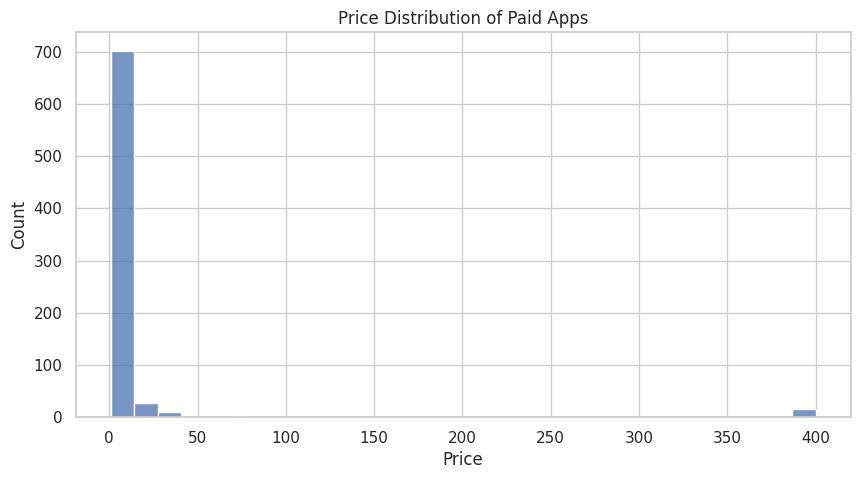

In [26]:
paid = df[df["Type"]=="Paid"]

plt.figure(figsize=(10,5))

sns.histplot(paid["Price"],bins=30)

plt.title("Price Distribution of Paid Apps")

plt.show()

In [27]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19.0,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7,5000000.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25.0,50000000.0,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
